# Cell Annotation Notebook

This notebook runs the original Sections 10–18 from the main pipeline in an independent file.
It loads a saved Seurat object from Section 9 and performs annotation, pathway scoring, GSEA, and pseudobulk DE.


In [47]:
library(Seurat)
library(harmony)
library(SingleR)
library(celldex)
library(scran)
library(DESeq2)
library(fgsea)
library(msigdbr)
library(tidyverse)
library(ggplot2)
library(ggrepel)
library(patchwork)
library(viridis)
library(BiocParallel)
library(dplyr)

set.seed(42)
register(MulticoreParam(4))  # Adjust to available cores

message("Libraries loaded.")


Libraries loaded.



## Load saved merged object

This notebook expects the merged Seurat object after Section 9 to be saved as `merged_after_section9.rds`.
If you have not saved it yet, run the main notebook through UMAP/clustering and save it with:
`saveRDS(merged, "merged_after_section9.rds")`


In [48]:
input_rds <- "data/merged_MV12.rds"
if (!file.exists(input_rds)) {
  stop(paste("Saved Seurat object not found:", input_rds))
}
merged <- readRDS(input_rds)
Idents(merged) <- "RNA_snn_res.0.3"
message("Loaded Seurat object from ", input_rds)
message("Active identity set to resolution 0.3")


Loaded Seurat object from data/merged_MV12.rds

Active identity set to resolution 0.3



## Section 1 — Automated Cell Type Annotation (SingleR)

SingleR compares each cell's log-normalized profile against bulk RNA-seq reference profiles of known cell types.
We use the **Monaco 2019 immune reference** for blood/PBMC annotation.

This method annotates cells by comparing individual single-cell expression profiles to a fixed reference atlas, rather than relying solely on manually defined cluster markers.
It is especially useful for immune datasets because it can identify common lymphoid and myeloid subtypes across samples.

The workflow below:
- loads the Monaco immune reference dataset
- joins Seurat v5 per-sample assay layers into unified `counts` and `data` layers
- converts the merged Seurat object to a `SingleCellExperiment`
- runs `SingleR` to infer cell labels and pruned low-confidence assignments

**Note:** The input merged object should already contain UMAP, Harmony, and clustering reductions from Section 9.


In [49]:
ref_monaco    <- celldex::MonacoImmuneData()

# Seurat v5 uses multiple per-sample assay layers, so join counts and data before conversion.
merged <- JoinLayers(merged, assay = "RNA", layers = c("counts", "data"))

sce_singler   <- as.SingleCellExperiment(merged)

singler_results <- SingleR(
  test    = sce_singler,
  ref     = ref_monaco,
  labels  = ref_monaco$label.main,   # Use label.fine for more granularity
  BPPARAM = MulticoreParam(4)
)

merged$singler_label  <- singler_results$labels
merged$singler_pruned <- singler_results$pruned.labels  # NAs = low confidence

message("SingleR annotation complete.")


Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

SingleR annotation complete.



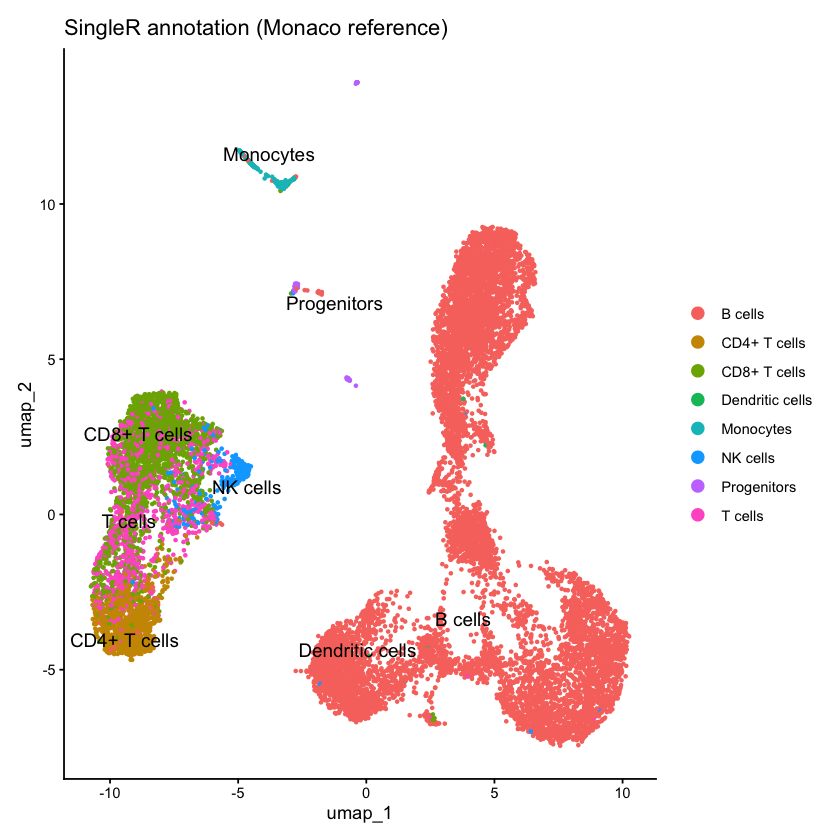

In [50]:
DimPlot(merged, reduction = "umap", group.by = "singler_label",
        label = TRUE, repel = TRUE, pt.size = 0.5) +
  ggtitle("SingleR annotation (Monaco reference)") +
  theme_classic()


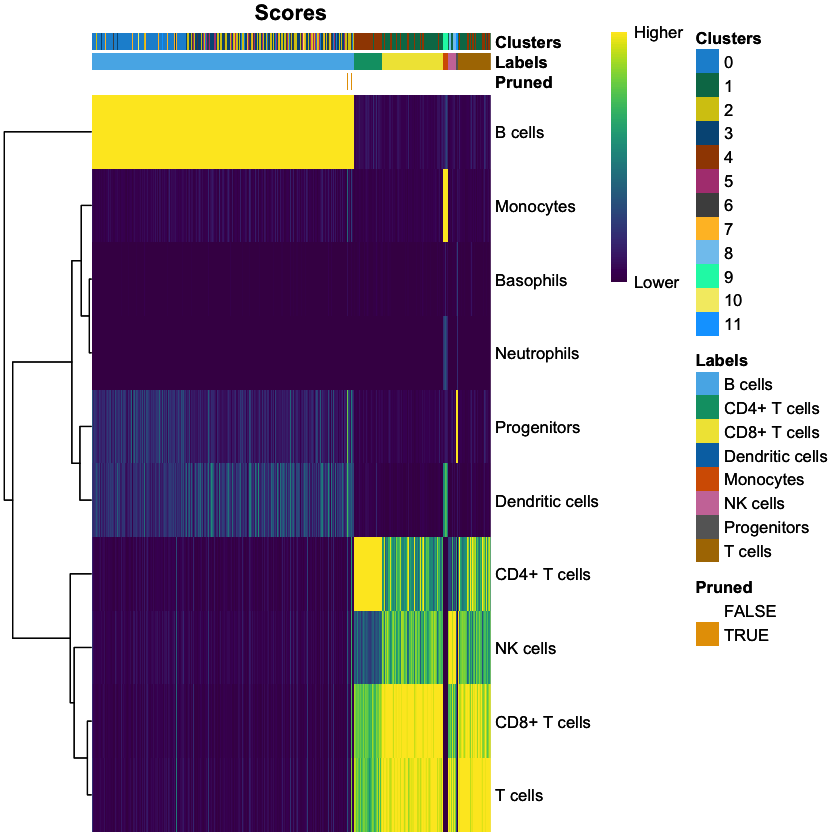

In [51]:
plotScoreHeatmap(singler_results,
                 clusters    = merged$RNA_snn_res.0.3,
                 show.pruned = TRUE)


In [52]:
cat("SingleR vs demux cell type comparison:
")
print(table(SingleR = merged$singler_label,
            Demux   = merged$celltype_demux))


SingleR vs demux cell type comparison:
                 Demux
SingleR           Bcell mega monocyte NKcell TcellCD4 TcellCD8
  B cells          9503    8        2     35       30       10
  CD4+ T cells       63    3        0      1      958        2
  CD8+ T cells      140    2        0      8      259     1782
  Dendritic cells     9    0        1      0        0        0
  Monocytes           0    0      178      0        0        1
  NK cells           68    4        1    178        3       37
  Progenitors         2   37        0     35        0        0
  T cells           206    0        0     26      340      618


## Section 2 — Manual Annotation with Canonical Markers

Validate and refine SingleR with canonical marker genes. CLL peripheral blood contains B cells, CD4 T cells, CD8 T cells, NK cells, and monocytes.
The CLL immunophenotype is **CD19⁺ CD5⁺ CD23⁺**.


Warning message:
“The following requested variables were not found: CD23”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


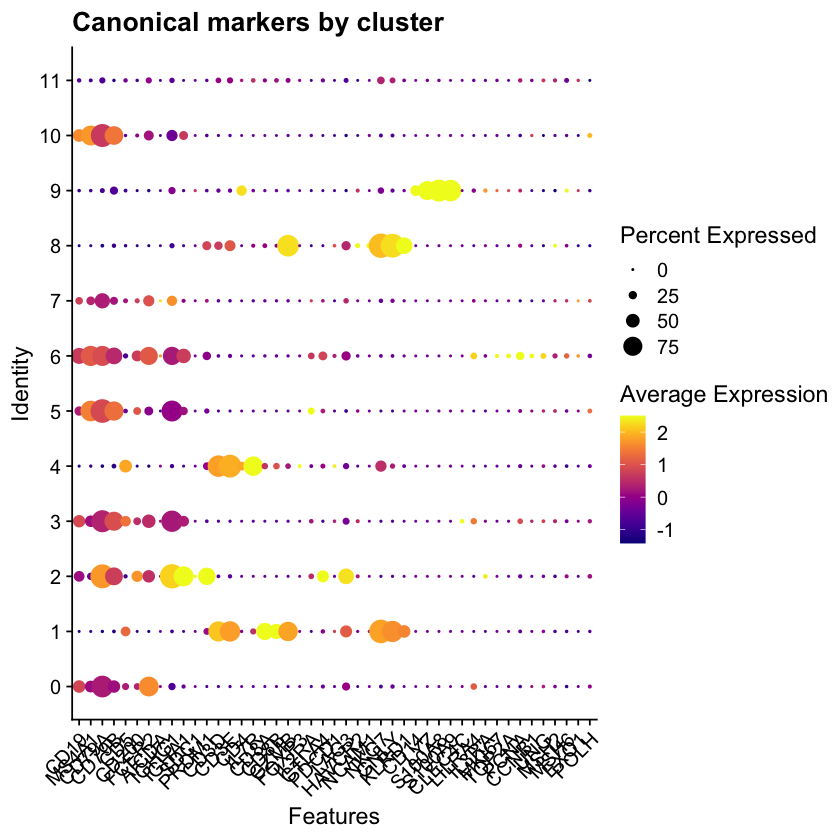

In [53]:
canonical_markers <- list(
  "B_general"     = c("CD19", "MS4A1", "CD79A", "CD79B"),
  "CLL_tumor"     = c("CD5", "CD23", "CD200", "FCER2"),    # CLL hallmark co-expression
  "AID_expressing"= c("AICDA"),                             # KEY gene for your study
  "Plasma_cell"   = c("IGHG1", "IGHA1", "SDC1", "PRDM1"),
  "T_CD4"         = c("CD3D", "CD3E", "CD4", "IL7R"),
  "T_CD8"         = c("CD3D", "CD8A", "CD8B", "GZMB"),
  "T_reg"         = c("FOXP3", "IL2RA", "CTLA4"),
  "T_exhausted"   = c("PDCD1", "LAG3", "HAVCR2"),
  "NK"            = c("NCAM1", "NKG7", "GNLY", "KLRD1"),
  "Monocyte"      = c("CD14", "LYZ", "S100A8", "S100A9"),
  "Dendritic"     = c("CLEC4C", "LILRA4", "IL3RA"),
  "Proliferating" = c("MKI67", "TOP2A", "PCNA", "CCNB1"),
  "AID_pathway"   = c("AICDA", "UNG", "MSH2", "MSH6", "EXO1", "POLH")
)

DotPlot(merged,
        features = unique(unlist(canonical_markers)),
        group.by = "RNA_snn_res.0.3",
        dot.scale = 6) +
  RotatedAxis() +
  scale_color_viridis(option = "plasma") +
  ggtitle("Canonical markers by cluster")


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


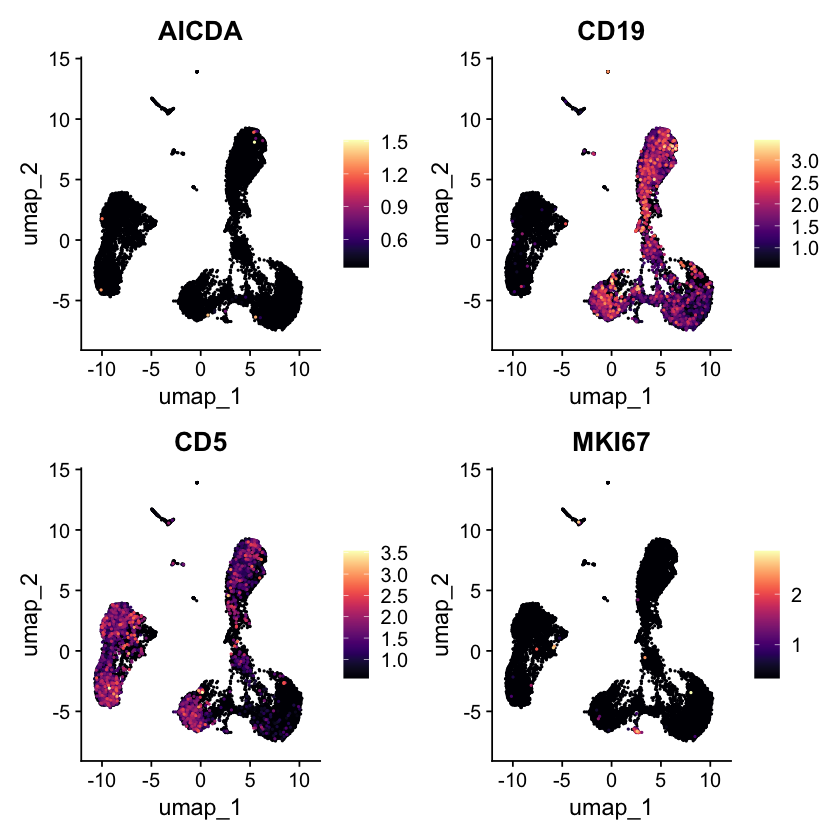

In [54]:
FeaturePlot(merged,
            features  = c("AICDA", "CD19", "CD5", "MKI67"),
            reduction = "umap",
            ncol      = 2,
            order     = TRUE,
            min.cutoff = "q05") &
  scale_color_viridis(option = "magma")


## Section 3 — Cluster Annotation and Tumor Cell Identification

Fill in the `cluster_annotation` vector after inspecting the plots. The labels below are a starting template.


AID+ cells: 20 (0.14% of all cells)



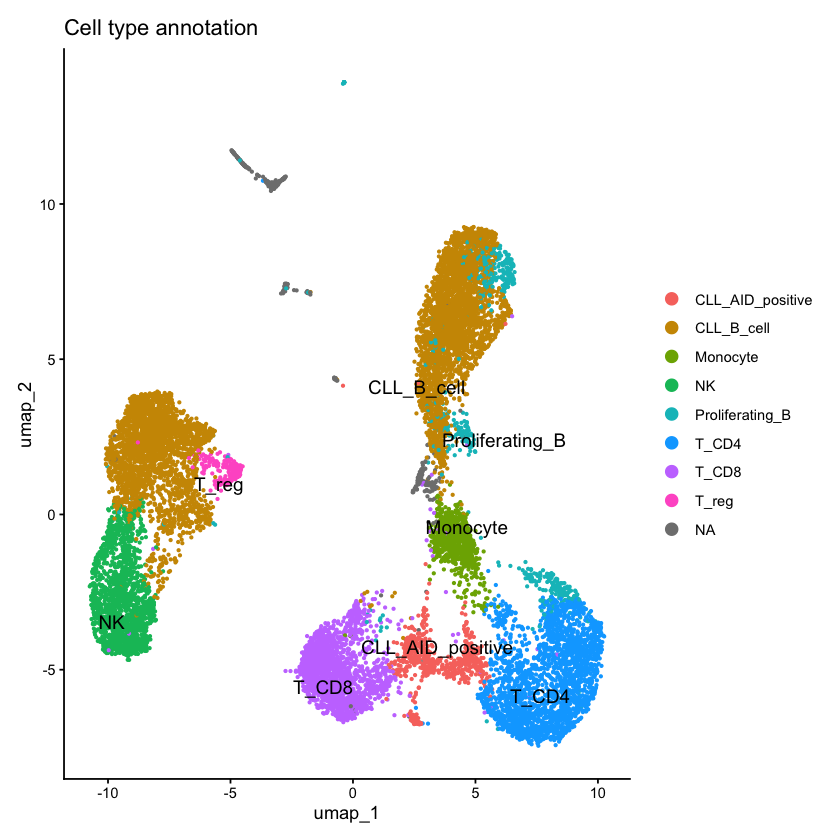

In [55]:
cluster_annotation <- c(
  "0" = "CLL_B_cell",        # CD19+ CD5+ CD23+ (tumor bulk)
  "1" = "CLL_B_cell",
  "2" = "T_CD4",
  "3" = "T_CD8",
  "4" = "NK",
  "5" = "Monocyte",
  "6" = "CLL_AID_positive",  # Cluster with detectable AICDA
  "7" = "Proliferating_B",   # MKI67+ B cells
  "8" = "T_reg"
)

merged$cell_type <- unname(cluster_annotation[as.character(merged$RNA_snn_res.0.3)])
merged$is_tumor <- merged$cell_type %in%
  c("CLL_B_cell", "CLL_AID_positive", "Proliferating_B")

aicda_expr <- FetchData(merged, vars = "AICDA")
merged$is_AID_positive <- aicda_expr$AICDA > 0
merged$is_proliferating <- merged$cell_type == "Proliferating_B"

message("AID+ cells: ", sum(merged$is_AID_positive),
        " (", round(mean(merged$is_AID_positive)*100, 2), "% of all cells)")

DimPlot(merged, reduction = "umap", group.by = "cell_type",
        label = TRUE, repel = TRUE, pt.size = 0.4) +
  ggtitle("Cell type annotation") + theme_classic()


## Section 4 — Proliferation Scoring


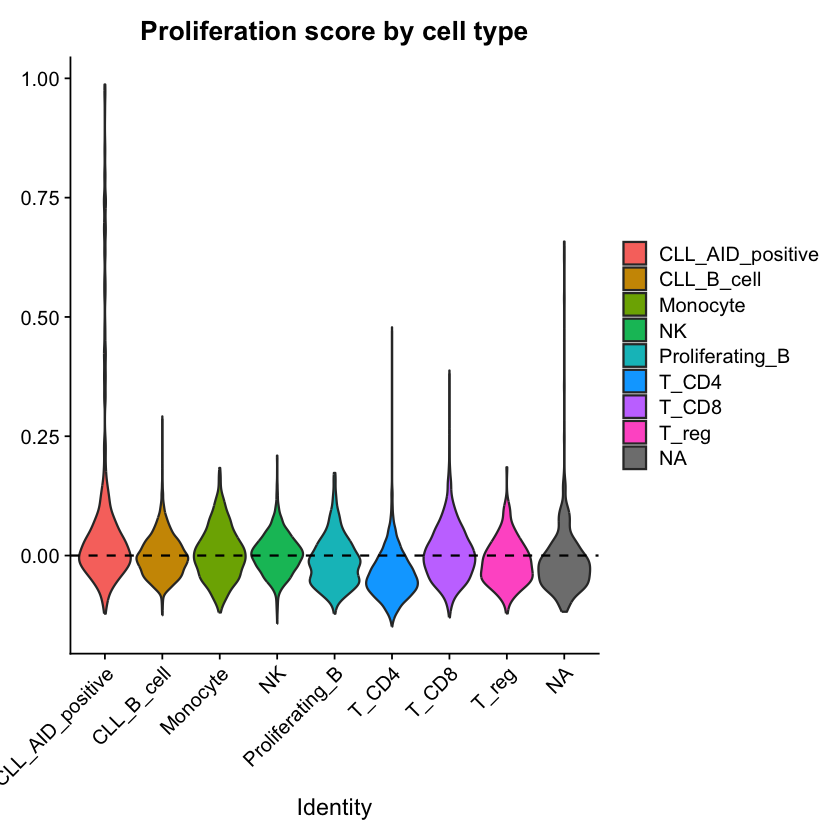

In [56]:
merged$prolif_score <- merged$S.Score + merged$G2M.Score

VlnPlot(merged, features = "prolif_score",
        group.by = "cell_type", pt.size = 0) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  ggtitle("Proliferation score by cell type")


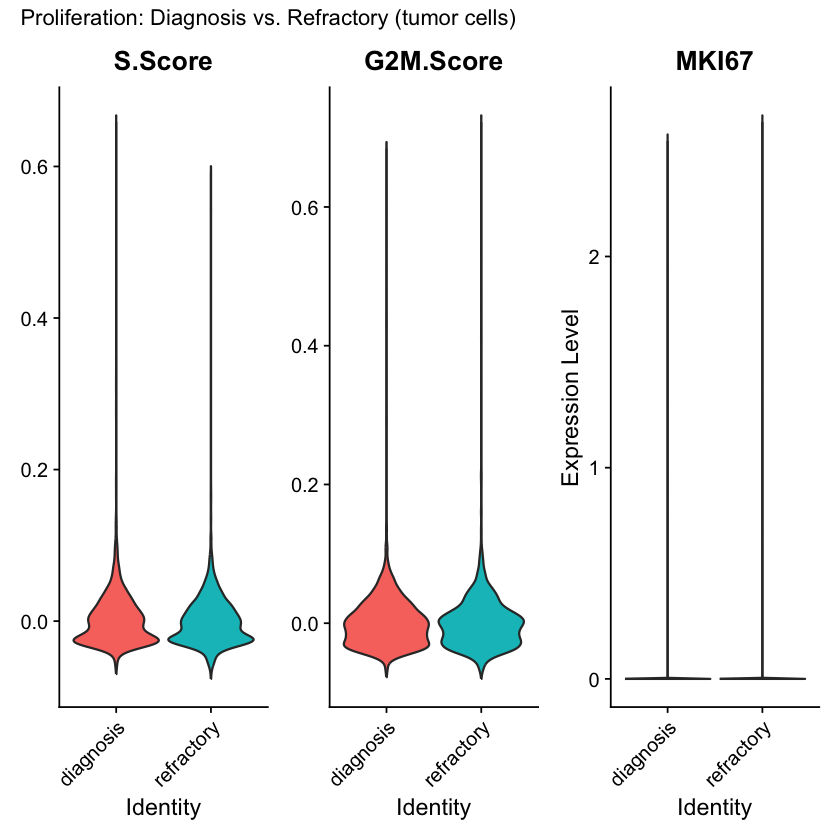

In [57]:
tumor_cells <- subset(merged, subset = is_tumor == TRUE)
VlnPlot(tumor_cells,
        features  = c("S.Score", "G2M.Score", "MKI67"),
        group.by  = "status",
        ncol      = 3,
        pt.size   = 0) +
  plot_annotation(title = "Proliferation: Diagnosis vs. Refractory (tumor cells)")


## B cell summary: AID-positive and proliferating fractions

Calculate how many B cells are AID-positive, proliferating, and non-proliferating relative to the annotated tumor B-cell population.


In [58]:
tumor_B_cells <- subset(merged, subset = cell_type %in% c("CLL_B_cell", "CLL_AID_positive", "Proliferating_B"))
n_tumor_B <- ncol(tumor_B_cells)
n_AID_positive_B <- sum(tumor_B_cells$is_AID_positive, na.rm = TRUE)
n_prolif_B <- sum(tumor_B_cells$cell_type == "Proliferating_B")
n_non_prolif_B <- n_tumor_B - n_prolif_B
n_AID_positive_prolif_B <- sum(tumor_B_cells$cell_type == "Proliferating_B" & tumor_B_cells$is_AID_positive, na.rm = TRUE)
cat("Tumor B cells:", n_tumor_B, "
")
cat("AID-positive tumor B cells:", n_AID_positive_B, "(", round(100 * n_AID_positive_B / n_tumor_B, 2), "% of tumor B cells)
")
cat("Proliferating tumor B cells:", n_prolif_B, "(", round(100 * n_prolif_B / n_tumor_B, 2), "% of tumor B cells)
")
cat("Non-proliferating tumor B cells:", n_non_prolif_B, "(", round(100 * n_non_prolif_B / n_tumor_B, 2), "% of tumor B cells)
")
cat("AID-positive among proliferating tumor B cells:", n_AID_positive_prolif_B, "(", round(100 * n_AID_positive_prolif_B / max(n_prolif_B, 1), 2), "% of proliferating tumor B cells)
")


Warning message:
“Removing 381 cells missing data for vars requested”


Tumor B cells: 7233 
AID-positive tumor B cells: 14 ( 0.19 % of tumor B cells)
Proliferating tumor B cells: 626 ( 8.65 % of tumor B cells)
Non-proliferating tumor B cells: 6607 ( 91.35 % of tumor B cells)
AID-positive among proliferating tumor B cells: 2 ( 0.32 % of proliferating tumor B cells)


## Section 5 — Pathway Enrichment (GSEA with fgsea)

Gene set enrichment analysis ranks all expressed genes by fold change between groups, then tests whether curated gene sets are concentrated at the top or bottom of that ranking.


In [59]:
hallmark_sets <- msigdbr(species = "Homo sapiens", category = "H") %>%
  split(x = .$gene_symbol, f = .$gs_name)

# Use the available KEGG subcategory for this msigdbr version.
kegg_sets <- msigdbr(species = "Homo sapiens", category = "C2",
                     subcategory = "CP:KEGG_LEGACY") %>%
  split(x = .$gene_symbol, f = .$gs_name)

message("Hallmark pathways: ", length(hallmark_sets))
message("KEGG pathways:     ", length(kegg_sets))


Hallmark pathways: 50

KEGG pathways:     186



In [60]:
run_gsea_comparison <- function(seurat_obj, group_col, group_a, group_b,
                                gene_sets, label = "") {
  message("
GSEA: ", label)
  if (!group_col %in% colnames(seurat_obj@meta.data)) {
    stop("Group column not found in Seurat metadata: ", group_col)
  }
  group_vals <- seurat_obj@meta.data[[group_col]]
  cells_a <- colnames(seurat_obj)[which(!is.na(group_vals) & group_vals == group_a)]
  cells_b <- colnames(seurat_obj)[which(!is.na(group_vals) & group_vals == group_b)]

  if (length(cells_a) < 10 | length(cells_b) < 10) {
    warning("Too few cells — skipping: ", label); return(NULL)
  }

  mat <- GetAssayData(seurat_obj, layer = "data")
  lfc    <- rowMeans(mat[, cells_a, drop=FALSE]) - rowMeans(mat[, cells_b, drop=FALSE])
  lfc    <- sort(lfc[!is.na(lfc) & is.finite(lfc)], decreasing = TRUE)

  set.seed(42)
  result <- fgsea(pathways = gene_sets, stats = lfc,
                  minSize = 15, maxSize = 500, eps = 0)
  result$comparison <- label
  result$group_a    <- group_a
  result$group_b    <- group_b
  return(result[order(result$pval), ])
}


In [61]:
# Recompute tumor metadata if this notebook section is run independently.
if (!"cell_type" %in% colnames(merged@meta.data)) {
  cluster_annotation <- c(
    "0" = "CLL_B_cell",
    "1" = "CLL_B_cell",
    "2" = "T_CD4",
    "3" = "T_CD8",
    "4" = "NK",
    "5" = "Monocyte",
    "6" = "CLL_AID_positive",
    "7" = "Proliferating_B",
    "8" = "T_reg"
  )
  merged$cell_type <- unname(cluster_annotation[as.character(merged$RNA_snn_res.0.3)])
}
if (!"is_tumor" %in% colnames(merged@meta.data)) {
  merged$is_tumor <- merged$cell_type %in%
    c("CLL_B_cell", "CLL_AID_positive", "Proliferating_B")
}
if (!"is_AID_positive" %in% colnames(merged@meta.data)) {
  aicda_expr <- FetchData(merged, vars = "AICDA")
  merged$is_AID_positive <- aicda_expr$AICDA > 0
}
if (!"is_proliferating" %in% colnames(merged@meta.data)) {
  merged$is_proliferating <- merged$cell_type == "Proliferating_B"
}

tumor_obj <- subset(merged, subset = is_tumor == TRUE)

gsea_dx_vs_ref_hallmark <- run_gsea_comparison(
  tumor_obj, "status", "diagnosis", "refractory",
  hallmark_sets, "Diagnosis_vs_Refractory_Hallmark")

gsea_dx_vs_ref_kegg <- run_gsea_comparison(
  tumor_obj, "status", "diagnosis", "refractory",
  kegg_sets, "Diagnosis_vs_Refractory_KEGG")



GSEA: Diagnosis_vs_Refractory_Hallmark

Warning message in prepareStats(stats, scoreType, gseaParam):
“There are ties in the preranked stats (1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”

GSEA: Diagnosis_vs_Refractory_KEGG

Warning message in prepareStats(stats, scoreType, gseaParam):
“There are ties in the preranked stats (1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [62]:
gsea_AID_hallmark <- run_gsea_comparison(
  tumor_obj, "is_AID_positive", "TRUE", "FALSE",
  hallmark_sets, "AID_pos_vs_AID_neg_Hallmark")



GSEA: AID_pos_vs_AID_neg_Hallmark

Warning message in prepareStats(stats, scoreType, gseaParam):
“There are ties in the preranked stats (1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 1 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”


### Proliferating vs non-proliferating tumor B cells

This comparison uses the tumor B-cell subset and contrasts cells annotated as `Proliferating_B` against the other tumor B cells.


In [63]:
tumor_obj$is_proliferating <- tumor_obj$cell_type == "Proliferating_B"

gsea_prolif_vs_nonprolif_hallmark <- run_gsea_comparison(
  tumor_obj,
  "is_proliferating",
  "TRUE",
  "FALSE",
  hallmark_sets,
  "Proliferating_vs_NonProliferating_Hallmark"
)

gsea_prolif_vs_nonprolif_kegg <- run_gsea_comparison(
  tumor_obj,
  "is_proliferating",
  "TRUE",
  "FALSE",
  kegg_sets,
  "Proliferating_vs_NonProliferating_KEGG"
)



GSEA: Proliferating_vs_NonProliferating_Hallmark

Warning message in prepareStats(stats, scoreType, gseaParam):
“There are ties in the preranked stats (1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”

GSEA: Proliferating_vs_NonProliferating_KEGG

Warning message in prepareStats(stats, scoreType, gseaParam):
“There are ties in the preranked stats (1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [65]:
gsea_P457 <- run_gsea_comparison(
  subset(tumor_obj, subset = patient == "S457"),
  "status", "Diagnosis", "Refractory",
  hallmark_sets, "S457_Dx_vs_Ref")

gsea_P477 <- run_gsea_comparison(
  subset(tumor_obj, subset = patient == "S477"),
  "status", "Diagnosis", "Refractory",
  hallmark_sets, "S477_Dx_vs_Ref")



GSEA: S457_Dx_vs_Ref



ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'table' in selecting a method for function '%in%': error in evaluating the argument 'x' in selecting a method for function 'colnames': None of the requested variables were found: 


## Section 6 — Per-Cell Pathway Scoring (IFN-α, IFN-γ, KRAS)


In [ ]:
hallmark_df <- msigdbr(species = "Homo sapiens", category = "H")
get_genes   <- function(name) {
  hallmark_df %>% filter(gs_name == name) %>% pull(gene_symbol) %>% unique() %>% list()
}

merged <- AddModuleScore(merged, get_genes("HALLMARK_INTERFERON_ALPHA_RESPONSE"), name="IFNa_score")
merged <- AddModuleScore(merged, get_genes("HALLMARK_INTERFERON_GAMMA_RESPONSE"),  name="IFNg_score")
merged <- AddModuleScore(merged, get_genes("HALLMARK_KRAS_SIGNALING_UP"),          name="KRAS_score")
merged <- AddModuleScore(merged, get_genes("HALLMARK_MYC_TARGETS_V1"),             name="MYC_score")
merged <- AddModuleScore(merged, get_genes("HALLMARK_APOPTOSIS"),                  name="Apoptosis_score")
merged <- AddModuleScore(merged, get_genes("HALLMARK_G2M_CHECKPOINT"),             name="G2M_score")

message("Module scores added. Note: Seurat appends '1' to each name.")


In [ ]:
FeaturePlot(merged,
            features   = c("IFNa_score1","IFNg_score1","KRAS_score1","MYC_score1"),
            reduction  = "umap",
            ncol       = 2,
            order      = TRUE,
            min.cutoff = "q05",
            max.cutoff = "q95") &
  scale_color_viridis(option = "magma") &
  theme_classic()


In [ ]:
tumor_obj <- subset(merged, subset = is_tumor == TRUE)

VlnPlot(tumor_obj,
        features = c("IFNa_score1","IFNg_score1","KRAS_score1"),
        group.by = "status", ncol = 3, pt.size = 0) +
  plot_annotation(title = "Pathway scores: Diagnosis vs. Refractory (tumor cells)")


In [ ]:
VlnPlot(tumor_obj,
        features = c("IFNa_score1","IFNg_score1","KRAS_score1"),
        group.by = "is_AID_positive", ncol = 3, pt.size = 0) +
  plot_annotation(title = "Pathway scores: AID+ vs AID- tumor cells")


## Section 7 — Visualize GSEA Results


In [ ]:
plot_gsea_bubble <- function(gsea_result, n_top = 20, title = "") {
  if (is.null(gsea_result)) { message("No result to plot."); return(invisible(NULL)) }
  df <- gsea_result %>%
    filter(!is.na(padj)) %>%
    arrange(padj) %>%
    head(n_top) %>%
    mutate(
      pathway_short = str_replace(pathway, "HALLMARK_|KEGG_", ""),
      direction     = ifelse(NES > 0, "Enriched in Group A", "Enriched in Group B")
    )
  ggplot(df, aes(x = NES, y = reorder(pathway_short, NES),
                 size = -log10(padj + 1e-10), color = direction)) +
    geom_point(alpha = 0.8) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
    scale_color_manual(values = c("Enriched in Group A" = "#E64B35",
                                  "Enriched in Group B" = "#4DBBD5")) +
    scale_size_continuous(range = c(2, 8), name = "-log10(FDR)") +
    labs(title = title, x = "NES", y = NULL, color = "Direction") +
    theme_classic(base_size = 11)
}

plot_gsea_bubble(gsea_dx_vs_ref_hallmark,
                 title = "Hallmark GSEA: Diagnosis vs. Refractory (tumor B cells)")


In [ ]:
plot_gsea_bubble(gsea_AID_hallmark,
                 title = "Hallmark GSEA: AID+ vs AID- tumor cells")


In [ ]:
if (!is.null(gsea_P457) & !is.null(gsea_P477)) {
  concordance <- merge(
    gsea_P457[, c("pathway","NES","padj")],
    gsea_P477[, c("pathway","NES","padj")],
    by = "pathway", suffixes = c("_P457", "_P477")
  )
  ggplot(concordance, aes(x = NES_P457, y = NES_P477, label = pathway)) +
    geom_point(aes(color = padj_P457 < 0.05 | padj_P477 < 0.05), size = 2) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
    geom_text_repel(
      data = concordance %>% filter(padj_P457 < 0.05 | padj_P477 < 0.05),
      aes(label = str_replace(pathway, "HALLMARK_", "")),
      size = 3, max.overlaps = 15
    ) +
    scale_color_manual(values = c("FALSE"="gray70","TRUE"="#E64B35"),
                       name = "FDR < 0.05 in either patient") +
    theme_classic() +
    ggtitle("NES concordance: P457 vs P477 (Dx vs Ref)")
}


## Section 8 — Pseudobulk Differential Expression (DESeq2)

For formal DE, **pseudobulk** is the gold standard. We collapse all cells from each biological sample into a single count profile, then run DESeq2 on the 4 sample-level profiles.
The design `~ patient + timepoint` controls for inter-patient variation.


In [ ]:
run_pseudobulk_DE <- function(seurat_obj, cell_subset,
                               comparison_col, group_a, group_b,
                               sample_col = "sample_id") {
  obj_sub   <- subset(seurat_obj, subset = cell_type %in% cell_subset)
  counts_pb <- AggregateExpression(obj_sub, assays = "RNA", slot = "counts",
                                   group.by = sample_col, return.seurat = FALSE)$RNA
  meta_df   <- seurat_obj@meta.data %>%
    select(all_of(c(sample_col, comparison_col, "patient", "chip"))) %>%
    distinct() %>%
    filter(!!sym(comparison_col) %in% c(group_a, group_b)) %>%
    column_to_rownames(sample_col)

  common        <- intersect(colnames(counts_pb), rownames(meta_df))
  counts_pb     <- counts_pb[, common]
  meta_df       <- meta_df[common, , drop = FALSE]
  meta_df[[comparison_col]] <- factor(meta_df[[comparison_col]],
                                       levels = c(group_b, group_a))

  dds <- DESeqDataSetFromMatrix(
    countData = round(counts_pb),
    colData   = meta_df,
    design    = as.formula(paste0("~ patient + ", comparison_col))
  )
  dds <- DESeq(dds, test = "LRT", reduced = as.formula("~ patient"))
  res <- results(dds, contrast = c(comparison_col, group_a, group_b), alpha = 0.05) %>%
    as.data.frame() %>% rownames_to_column("gene") %>% arrange(padj)

  return(list(dds = dds, results = res))
}


In [ ]:
de_dx_vs_ref <- run_pseudobulk_DE(
  seurat_obj     = merged,
  cell_subset    = c("CLL_B_cell","CLL_AID_positive","Proliferating_B"),
  comparison_col = "status",
  group_a        = "Diagnosis",
  group_b        = "Refractory"
)

cat("Top DE genes (Diagnosis vs Refractory, tumor cells):
")
print(head(de_dx_vs_ref$results %>% filter(padj < 0.05), 20))


In [ ]:
de_res <- de_dx_vs_ref$results %>%
  mutate(sig = case_when(
    padj < 0.05 & log2FoldChange >  1 ~ "Up in Dx",
    padj < 0.05 & log2FoldChange < -1 ~ "Up in Ref",
    TRUE ~ "NS"))

ggplot(de_res, aes(x = log2FoldChange, y = -log10(padj + 1e-300), color = sig)) +
  geom_point(alpha = 0.6, size = 0.8) +
  scale_color_manual(values = c("Up in Dx"="#E64B35","Up in Ref"="#4DBBD5","NS"="gray70")) +
  geom_vline(xintercept = c(-1,1), linetype="dashed") +
  geom_hline(yintercept = -log10(0.05), linetype="dashed") +
  geom_text_repel(
    data = de_res %>% filter(padj < 0.01 & abs(log2FoldChange) > 2),
    aes(label = gene), size = 3, max.overlaps = 20
  ) +
  theme_classic() +
  ggtitle("DESeq2 pseudobulk: Diagnosis vs. Refractory (tumor B cells)")


## Section 9 — Save All Outputs


In [ ]:
saveRDS(merged, "CLL_scRNAseq_merged_annotated.rds")

if (!is.null(gsea_dx_vs_ref_hallmark))
  write.csv(gsea_dx_vs_ref_hallmark, "GSEA_Hallmark_Dx_vs_Ref_tumor.csv", row.names=FALSE)
if (!is.null(gsea_AID_hallmark))
  write.csv(gsea_AID_hallmark, "GSEA_Hallmark_AID_pos_vs_neg.csv", row.names=FALSE)
if (!is.null(gsea_dx_vs_ref_kegg))
  write.csv(gsea_dx_vs_ref_kegg, "GSEA_KEGG_Dx_vs_Ref_tumor.csv", row.names=FALSE)

write.csv(de_dx_vs_ref$results, "DESeq2_pseudobulk_Dx_vs_Ref_tumor.csv", row.names=FALSE)

module_df <- FetchData(merged,
  vars = c("cell_type","patient","status","is_AID_positive","IFNa_score1","IFNg_score1","KRAS_score1","MYC_score1","Apoptosis_score1","G2M_score1","prolif_score"))
write.csv(module_df, "pathway_scores_per_cell.csv")

writeLines(capture.output(sessionInfo()), "sessionInfo.txt")

message("
=== Pipeline complete ===")
message("Saved files:")
for (f in c("CLL_scRNAseq_merged_annotated.rds","GSEA_Hallmark_Dx_vs_Ref_tumor.csv","GSEA_Hallmark_AID_pos_vs_neg.csv","GSEA_KEGG_Dx_vs_Ref_tumor.csv","DESeq2_pseudobulk_Dx_vs_Ref_tumor.csv","pathway_scores_per_cell.csv","sessionInfo.txt")) message("  ", f)
